In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('placement.csv')

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [6]:
#preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
df=df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [12]:
#EDA
import matplotlib.pyplot as plt

Text(0, 0.5, 'iq')

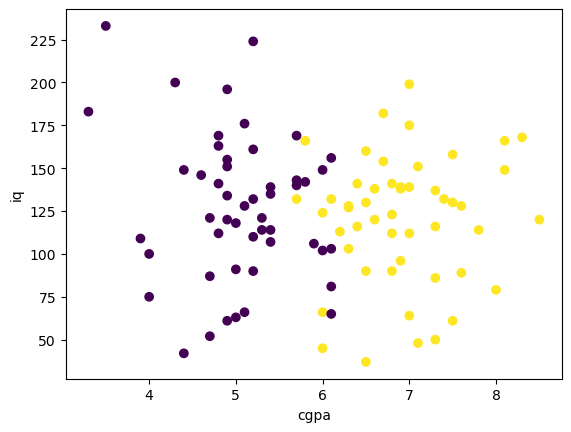

In [18]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])
plt.xlabel('cgpa')
plt.ylabel('iq')

In [29]:
#Extract input and output cols
x=df.iloc[:,0:2]
y=df.iloc[:,2]

In [30]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [43]:
y.shape

(100,)

In [44]:
#Train test split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1) # test_size=0.1 this means 10% data goes to test and 90%data goes to training data

In [45]:
x_train

,cgpa,iq
4,5.8,142.0
92,5.2,110.0
45,6.0,66.0
48,6.6,138.0
31,3.9,109.0
...,...,...
9,5.1,66.0
67,5.0,118.0
91,7.5,158.0
72,7.3,116.0


In [46]:
x_test

,cgpa,iq
43,6.8,141.0
62,6.0,102.0
84,5.7,169.0
93,6.8,112.0
23,4.7,87.0
52,7.0,175.0
7,5.0,63.0
98,6.3,103.0
87,5.7,132.0
51,4.8,141.0


In [47]:
y_train

4     0
92    0
45    1
48    1
31    0
     ..
9     0
67    0
91    1
72    1
13    1
Name: placement, Length: 90, dtype: int64

In [48]:
#Scale the values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
     
x_train = scaler.fit_transform(x_train)

In [49]:
x_train

array([[-0.17406632,  0.45351632],
       [-0.68770462, -0.33951768],
       [-0.00285355, -1.42993943],
       [ 0.51078476,  0.35438707],
       [-1.80058763, -0.36429999],
       [ 0.76760392,  0.37916938],
       [ 0.42517838,  0.15612857],
       [-0.77331101,  1.29611494],
       [ 0.8532103 ,  0.37916938],
       [-1.11573655, -1.7768918 ],
       [-0.94452378, -0.09169456],
       [-1.3725557 , -2.02471492],
       [ 1.79488054,  1.04829181],
       [-0.51649186,  0.28004013],
       [-0.77331101,  0.10656394],
       [ 1.28124223, -1.55385099],
       [-0.60209824, -0.06691224],
       [-0.85891739, -0.81038162],
       [-0.00285355,  0.00743469],
       [-0.60209824, -0.24038843],
       [-0.94452378,  1.79176119],
       [ 0.08275284, -1.05820474],
       [ 0.33957199,  0.428734  ],
       [ 0.93881669,  0.67655713],
       [-1.20134293,  0.55264557],
       [-0.68770462,  0.92438025],
       [-0.00285355,  0.6269925 ],
       [ 1.53806138, -0.24038843],
       [ 1.96609331,

In [50]:
x_test=scaler.transform(x_test)

In [51]:
x_test

array([[ 0.68199753,  0.428734  ],
       [-0.00285355, -0.53777618],
       [-0.2596727 ,  1.12263875],
       [ 0.68199753, -0.28995306],
       [-1.11573655, -0.90951087],
       [ 0.8532103 ,  1.27133263],
       [-0.85891739, -1.50428636],
       [ 0.25396561, -0.51299387],
       [-0.2596727 ,  0.20569319],
       [-1.03013016,  0.428734  ]])

In [53]:
#model training
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [54]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
# model evaluation
y_pred = clf.predict(x_test)
y_pred

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0])

In [63]:
y_test

43    1
62    0
84    0
93    1
23    0
52    1
7     0
98    1
87    1
51    0
Name: placement, dtype: int64

In [61]:

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8

<Axes: >

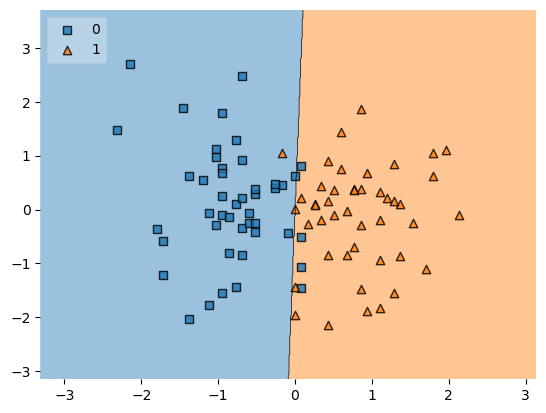

In [65]:

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [66]:
#Save model using Pickle
import pickle
pickle.dump(clf,open('model.pkl','wb'))
     